# Homework 1

### Consegna

Zeri di funzione: utilizzare il metodo di bisezione, il metodo delle iterazioni di punto fisso e il metodo di Newton per il calcolo dello zero delle seguenti funzioni.
Disegnare il grafico della funzione per localizzare lo zero e scegliere sia l'intervallo in cui applicare la bisezione che il punto iniziale per gli altri due algoritmi.

1. $f(x) = ln(x+1) - x    (g(x) = ln(x+1))$

2. $f(x) = x^2 -cos(x)   (g(x) = \sqrt{cos(x)})$

3. $f(x) = sin(x)-x/2  (g(x) = 2sin(x))$

4. $f(x) = e^x-3x  (g(x) = e^x/3)$



## Codici degli algoritmi

Metodo di bisezione

In [1]:
def metodo_bisezione(f, a, b, max_iter, epsilon):
    cond = True
    i = 0
    if f(a) * f(b) >= 0.0:
        return None, 0
    while cond and i < max_iter:
        c = (a + b) / 2
        if abs(f(c)) < epsilon:
            cond = False
        if cond and f(a) * f(c) < 0:
            b = c
        elif cond:
            a = c
        i = i + 1
    return c, i

Metodo punto fisso

In [2]:
def metodo_punto_fisso(f, g, x0, max_iter, epsilon1, epsilon2):
    i = 0
    cond = True
    xk = x0
    while cond and i < max_iter:
        x = g(xk)
        if abs(x - xk) < epsilon1 or abs(f(x)) < epsilon2:
            cond = False
        else:
            xk = x
            i = i + 1
    return xk, i

Metodo di Newton

In [3]:
def metodo_newton(f, df, x0, max_iter, epsilon1, epsilon2):
    i = 0
    cond = True
    xk = x0
    if abs(df(xk)) < 1e-10:
        return None, 0
    while cond and i < max_iter:
        xk1 = xk - f(xk) / df(xk)
        if abs(xk1 - xk) < epsilon1 or abs(f(xk1)) < epsilon2:
            cond = False
        else:
            xk = xk1
            i = i + 1
    return xk, i

Funzione per stampare $f(x)$ e $g(x)$

In [4]:
import numpy as np
import matplotlib.pyplot as plt


def sp(f, g, df, alfa=-10, beta=10, d=6):

    x = np.linspace(alfa, beta, 100)
    with np.errstate(invalid='ignore', divide='ignore'):
        fx = f(x)
        gx = g(x)
        dfx = df(x)
    fx = np.where(np.isfinite(fx), fx, np.nan)
    gx = np.where(np.isfinite(gx), gx, np.nan)
    dfx = np.where(np.isfinite(dfx), dfx, np.nan)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title("Funzione f(x)")
    plt.plot(x, fx, 'g', label='y = f(x)')
    y = np.zeros_like(x)
    plt.plot(x, y, 'yellow', label='y = 0')
    plt.xlim(-d, d)
    plt.ylim(-d, d)
    plt.legend()
    plt.grid()

    plt.subplot(1, 3, 2)
    plt.title("Funzione g(x)")
    plt.plot(x, gx, 'orange', label='y = g(x)')
    plt.xlim(-d, d)
    plt.ylim(-d, d)
    plt.legend()
    plt.grid()

    plt.subplot(1, 3, 3)
    plt.title("Funzione df(x)")
    plt.plot(x, dfx, 'purple', label='y = df(x)')
    plt.xlim(-d, d)
    plt.ylim(-d, d)

    plt.legend()
    plt.grid()
    plt.show()

Implementazione dei metodi con plt per mostrare i risultati dell'esecuzione del metodo

In [5]:
def metodo_bisezione(f, a, b, max_iter, epsilon):
    x = np.linspace(a, b, 400)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title ("Metodo di Bisezione")
    plt.plot (x, f(x), 'b')
    y = np.zeros_like(x)
    plt.plot(x, y, 'yellow', label='y = 0')
    plt.xlim(a, b) 
    if f(a) < f(b):
        plt.ylim(f(a), f(b)) 
    else:
        plt.ylim(f(b), f(a))
    
    fk = np.zeros(max_iter+1)
    cn = True
    cond = True
    i = 0
    print("\nMetodo di Bisezione:")
    print(f"a = {a}, b = {b}")
    if f(a) * f(b) > 0.0:
        print("Il metodo di bisezione non può essere applicato.")
        return None, 0, fk
    elif abs(f(a) * f(b)) < epsilon:
        if f(a) == 0.0:
            print(f"Lo zero calcolato è {a}")
            plt.plot(a, f(a), 'or', label='Convergenza')
            cond = False
            c = a
        else:
            print(f"Lo zero calcolato è {b}")
            plt.plot(b, f(b), 'or', label='Convergenza')
            return b, 0, fk
    while cond and i < max_iter:
        c = (a + b) / 2
        plt.plot(c, f(c), 'og')
        if abs(f(c)) < epsilon:
            print(f"Convergenza raggiunta dopo {i+1} iterazioni.")
            print(f"Lo zero calcolato è {c}")
            cn = False
            cond = False
            plt.plot(c, f(c), 'or', label='Convergenza')

        if cond and f(a) * f(c) < 0:
            b = c
        elif cond:
            a = c
        if cond:
            fk[i] = abs(f(c))
        i = i + 1 


    if cn and i == max_iter:
        print("Numero massimo di iterazioni raggiunto senza convergenza.")
        print(f"Lo zero calcolato è {c}")
    
    plt.grid()
    plt.legend()
    
    return c, i, fk[:i+1]



def metodo_punto_fisso(f, g, x0, max_iter, epsilon1, epsilon2, alfa, beta):

    x = np.linspace(alfa, beta, 400)
    plt.subplot(1, 3, 2)
    plt.title ("Metodo delle Iterazioni di Punto Fisso")
    y = np.zeros_like(x)
    plt.plot(x, y, 'yellow', label='y = 0')
    plt.plot (x, x, 'green', label='y = x')
    plt.plot (x, f(x), 'blue', label='y = f(x)')
    plt.plot (x, g(x), 'orange', label='y = g(x)')

    print("\nMetodo delle Iterazioni di Punto Fisso:")
    i = 0
    cond = True
    xk = x0
    fk = np.zeros(max_iter+1)
    fk[0] = abs(f(x0))
    while (cond and i < max_iter):
        x = g(xk)
        if (np.isfinite(x) == False):
            if i == 0:
                print("Il metodo delle iterazioni di punto fisso non può essere applicato.")
                print("Punto iniziale non appartiene al dominio della funzione g(x).")
            else:
                print("Il metodo delle iterazioni di punto fisso non converge.")
            xk = None
            break
        
        plt.plot ([xk, xk], [xk, g(xk)], 'r-')
        plt.plot ([xk, g(xk)], [g(xk), g(xk)], 'r-')


        if abs(f(x)) < epsilon2 or abs(x - xk) < epsilon1:
            print(f"Convergenza raggiunta dopo {i+1} iterazioni")
            print(f"Lo zero calcolato è {x}")
            plt.axvline(x=x, color='red', linestyle='--')
            plt.plot(x, f(x), 'ro', label='Convergenza')
            cond = False
        elif cond:
            fk[i+1] = abs(f(x))
        xk = x
        i = i + 1

    if cond and i == max_iter:
        print("Numero massimo di iterazioni raggiunto senza convergenza.")
        print(f"Ultimo valore calcolato è {xk}")

    d = 2
    plt.xlim(-d, d)  
    plt.ylim(-d, d)  
    plt.grid()
    plt.legend()
    return xk, i, fk[:i+1]


def metodo_newton(f, df, x0, max_iter, epsilon1, epsilon2, alfa, beta):

    x = np.linspace(alfa, beta, 400)
    plt.subplot(1, 3, 3)
    plt.title ("Metodo di Newton")
    plt.plot(x0, 0, marker='o', color='pink', linestyle='None', label='Punto iniziale')
    y = np.zeros_like(x)
    plt.plot(x, y, 'yellow', label='y = 0')
    plt.plot (x, f(x), 'blue', label='y = f(x)')
    print("\nMetodo di Newton:")
    i = 0
    cond = True
    xk = x0
    f_xk = np.zeros(max_iter+1)
    f_xk[0] = abs(f(xk))
    if abs(df(xk)) < 1e-10:
        print("La derivata è zero. Il metodo di Newton non può essere applicato.")
        plt.legend()
        plt.grid()
        plt.show()
        return None, 0, []
    while cond and i < max_iter:
        df_xk = df(xk)
        plt.plot(xk, f(xk), 'yo') 
        tangente = df_xk * (x - xk) + f(xk)
        plt.plot(x, tangente, 'b', linestyle='--')
        xk1 = xk - f(xk) / df(xk)
        f_xk[i+1] = abs(f(xk1))
        if abs(xk1 - xk) < epsilon1:
            print(f"Convergenza raggiunta dopo {i+1} iterazioni.")
            print(f"Lo zero calcolato è {xk1}")
            plt.plot(xk1, f(xk1), 'ro', label='Convergenza')
            cond = False

        if abs(f(xk1)) < epsilon2:
            print(f"Convergenza raggiunta dopo {i+1} iterazioni")
            print(f"Lo zero calcolato è {xk1}")
            plt.plot(xk1, f(xk1), 'ro', label='Convergenza')
            cond = False

        i = i + 1
        xk = xk1

    d = 2
    plt.xlim(-d, d)  
    plt.ylim(-d, d) 
    plt.grid()
    plt.show()

    
    return xk, i, f_xk[:i+1]


Creo una funzione che richiemi i tre metodi e stampo i risultati delle esecuzioni

In [6]:
def homework1(f, df, g, x0, max_iter, epsilon, alfa, beta, epsilon1, epsilon2, a, b):
    
    sol1, n_iter1, fk1 = metodo_bisezione(f, a, b, max_iter, epsilon)
    sol2, n_iter2, fk2 = metodo_punto_fisso(f, g, x0, max_iter, epsilon1, epsilon2, alfa, beta)
    sol3, n_iter3, fk3 = metodo_newton(f, df, x0, max_iter, epsilon1, epsilon2, alfa, beta)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1)
    plt.title ("Bisezione")
    fk = fk1[:n_iter1+1] 
    plt.plot(range(n_iter1+1), fk, 'm', label='Valori f(xk) ad ogni iterazione')
    plt.legend()
    plt.grid()



    plt.subplot(1, 3, 2)
    plt.title ("Punto Fisso")
    fk = fk2[:n_iter2+1] 
    plt.plot(range(n_iter2+1), fk, 'm', label='Valori f(xk) ad ogni iterazione')
    plt.legend()
    plt.grid()

    if (n_iter3 > 0): n_iter3 += 1
    plt.subplot(1, 3, 3)
    plt.title ("Newton")
    fk = fk3[:n_iter3]
    plt.plot(range(n_iter3), fk, 'm', label='Valori f(xk) ad ogni iterazione')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    n_iter3 -= 1


    risultati = np.array([
        [sol1, n_iter1,  None],
        [sol2, n_iter2,  x0],
        [sol3, n_iter3,  x0]
    ])

    intestazioni = ["Soluzione", "Iterazioni", "Punto iniziale"]

    fig, ax = plt.subplots()

    ax.axis('tight')
    ax.axis('off')

    tabella = ax.table(
        cellText=risultati,
        colLabels=intestazioni,
        loc='center',
        cellLoc='center'
    )

    tabella.auto_set_font_size(False)
    tabella.set_fontsize(12)
    tabella.scale(1.2, 1.2)

    plt.show()

Prima funzione


1. $f(x) = ln(x+1) - x       (g(x) = ln(x+1))$


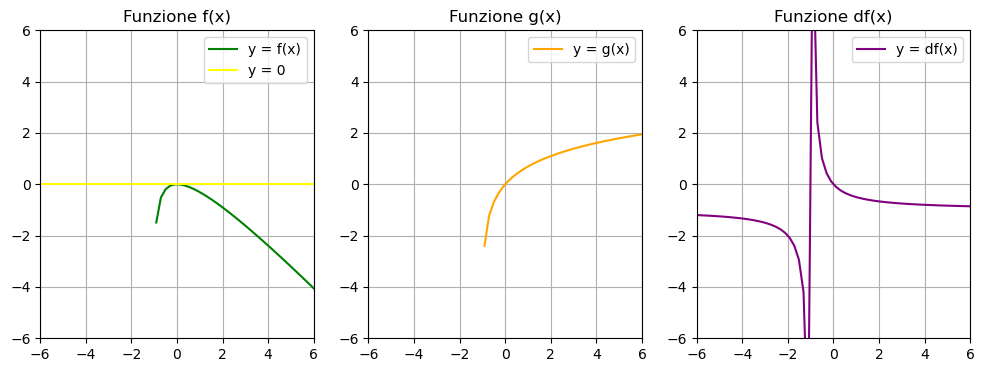

In [7]:
f = lambda x: np.log(np.where(x > -1, x + 1, np.nan)) - x
df = lambda x: 1/(x+1) - 1
g = lambda x: np.log(np.where(x > -1, x + 1, np.nan))

sp(f, g, df)

Variazione del punto iniziale e intervallo


Metodo di Bisezione:
a = 0, b = 1
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 1 iterazioni
Lo zero calcolato è 0.0

Metodo di Newton:
La derivata è zero. Il metodo di Newton non può essere applicato.


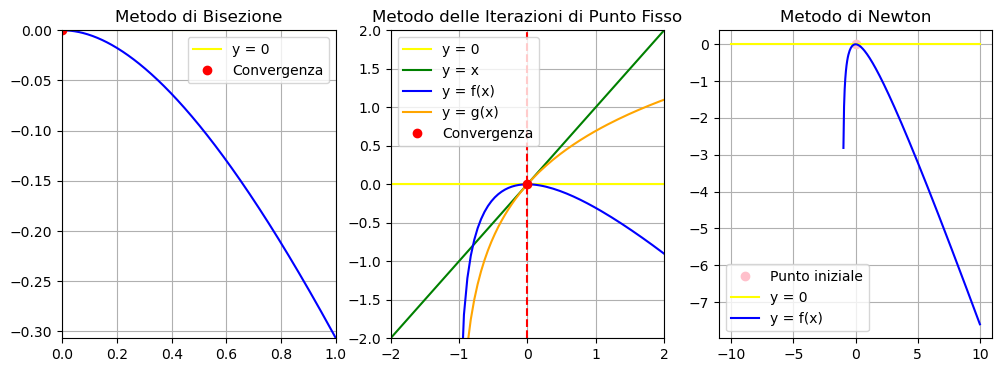

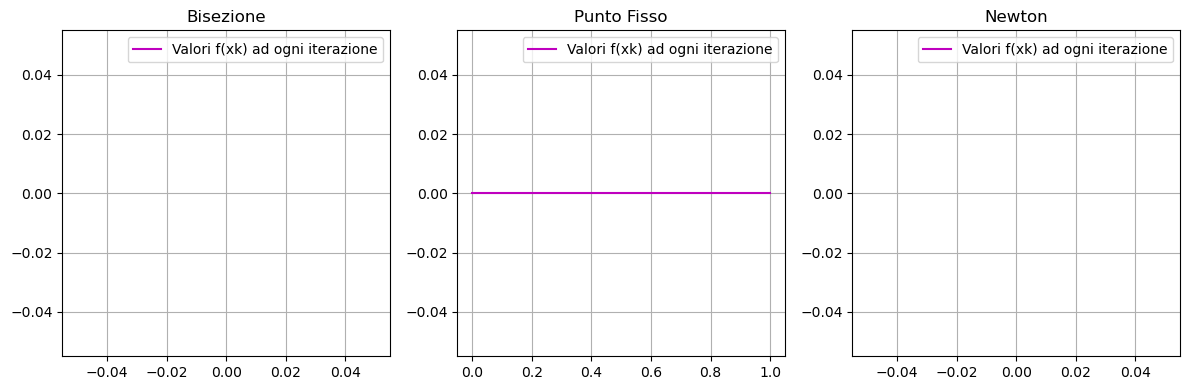

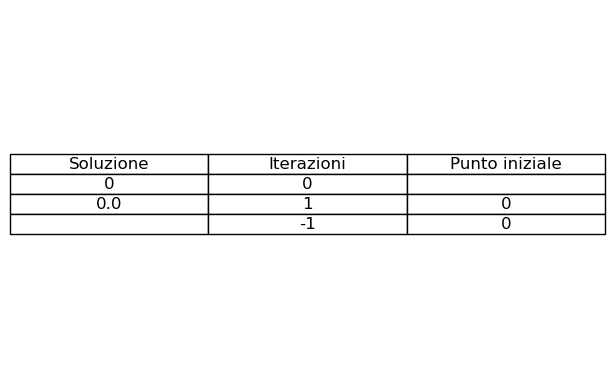


Metodo di Bisezione:
a = 0, b = 1
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Numero massimo di iterazioni raggiunto senza convergenza.
Ultimo valore calcolato è 0.019430625641093668

Metodo di Newton:
Convergenza raggiunta dopo 9 iterazioni
Lo zero calcolato è 0.0007411225759261306


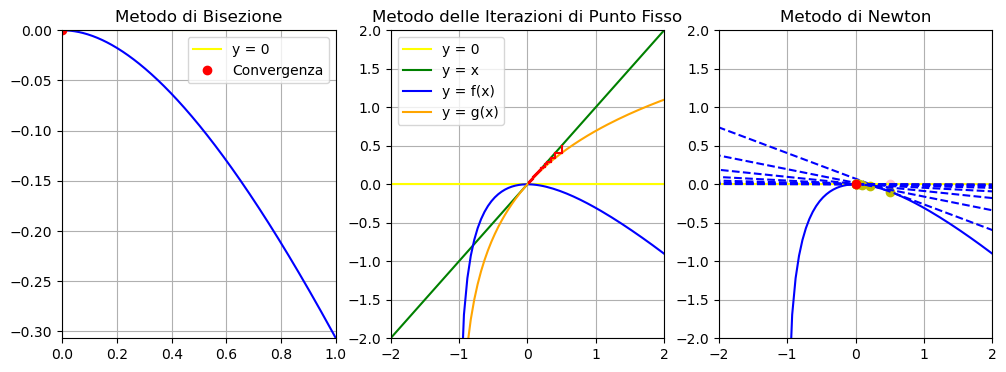

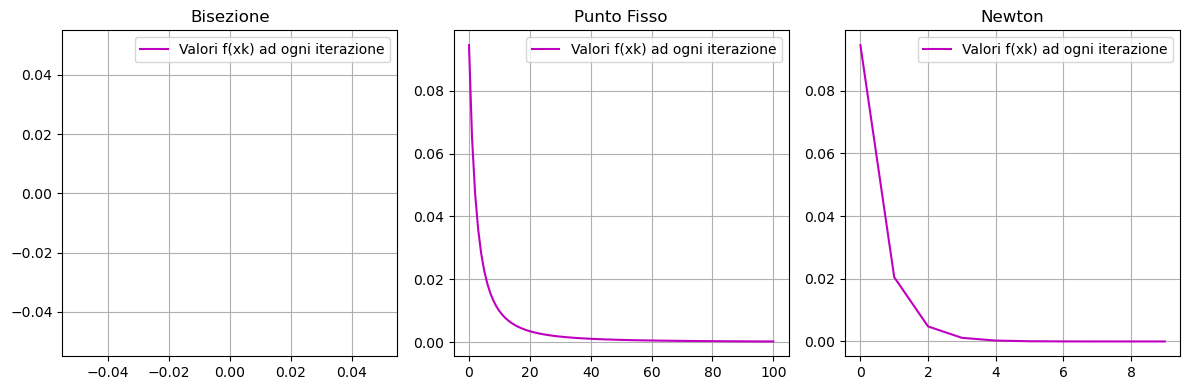

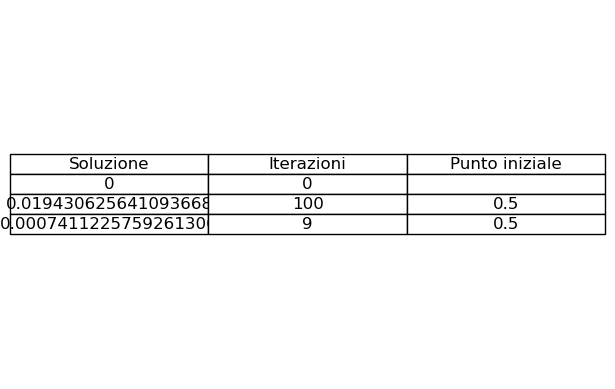


Metodo di Bisezione:
a = -0.8, b = 0
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Il metodo delle iterazioni di punto fisso non converge.

Metodo di Newton:
Convergenza raggiunta dopo 10 iterazioni
Lo zero calcolato è -0.0007610101397186372


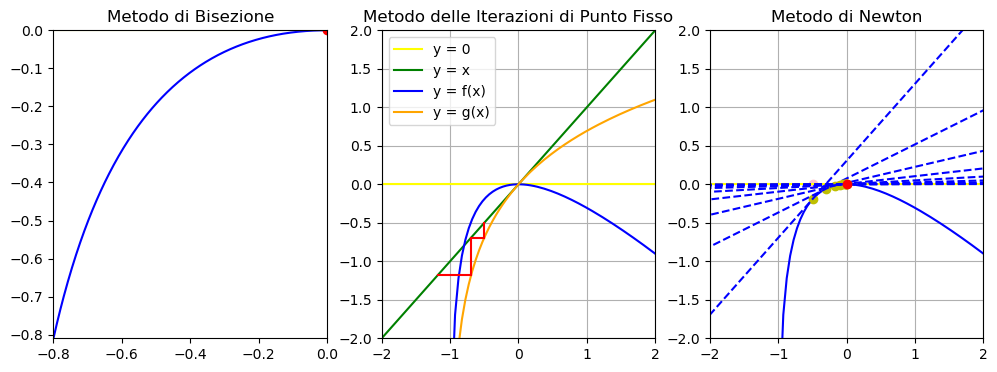

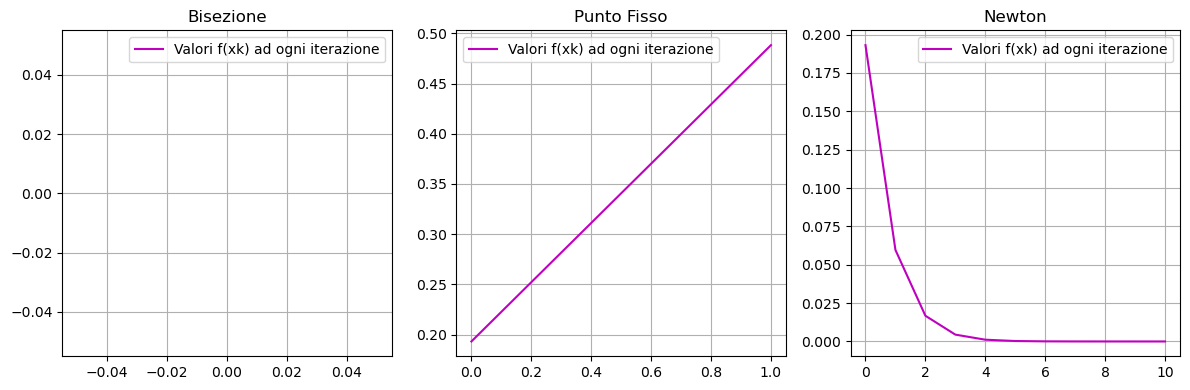

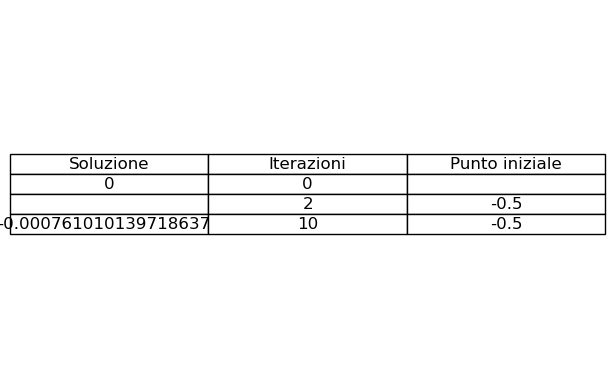


Metodo di Bisezione:
a = 1, b = 2
Il metodo di bisezione non può essere applicato.

Metodo delle Iterazioni di Punto Fisso:
Numero massimo di iterazioni raggiunto senza convergenza.
Ultimo valore calcolato è 0.020013729053473997

Metodo di Newton:
Convergenza raggiunta dopo 8 iterazioni
Lo zero calcolato è 0.0030914604878293666


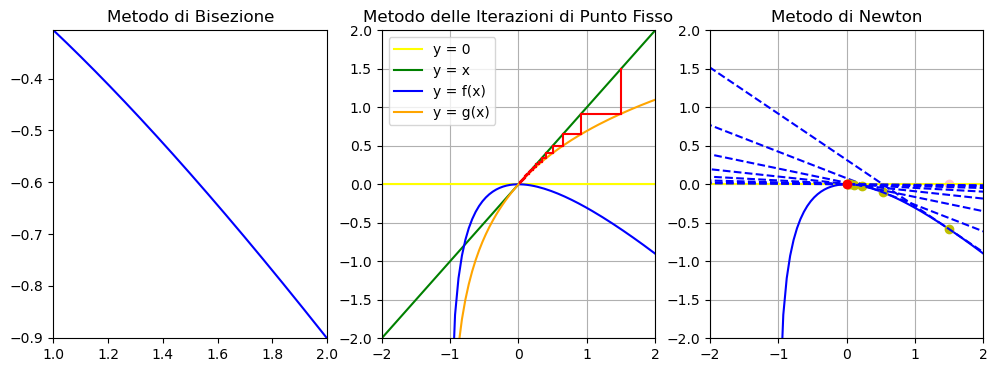

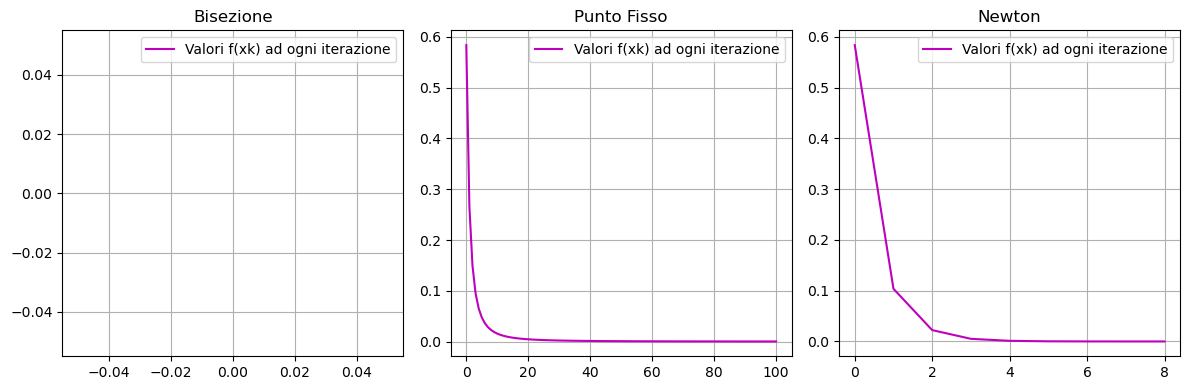

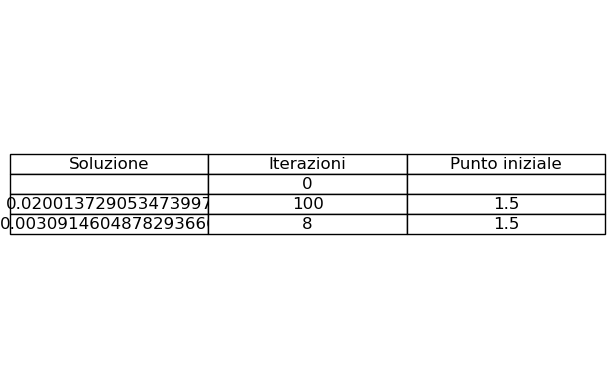

In [8]:

homework1(f, df, g, x0=0, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=0.5, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=-0.5, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=-0.8, b=0)
homework1(f, df, g, x0=1.5, max_iter=100, epsilon=1e-5, alfa=-10, beta=10, epsilon1=1e-5, epsilon2=1e-5, a=1, b=2)

Variazione della tolleranza


Metodo di Bisezione:
a = 0, b = 1
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Numero massimo di iterazioni raggiunto senza convergenza.
Ultimo valore calcolato è 0.019430625641093668

Metodo di Newton:
Convergenza raggiunta dopo 5 iterazioni
Lo zero calcolato è 0.011946374356847485


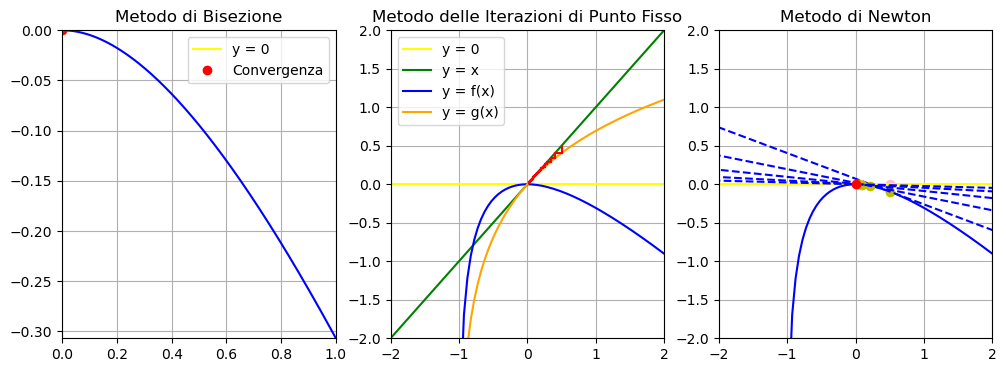

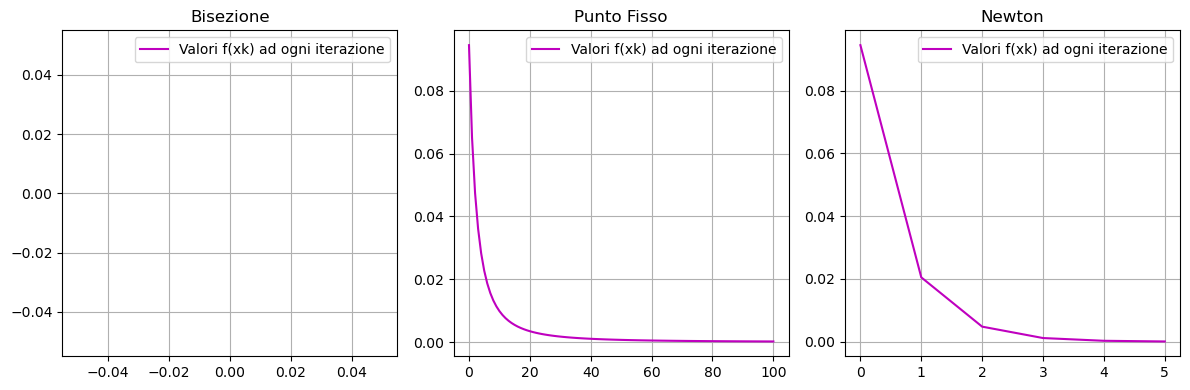

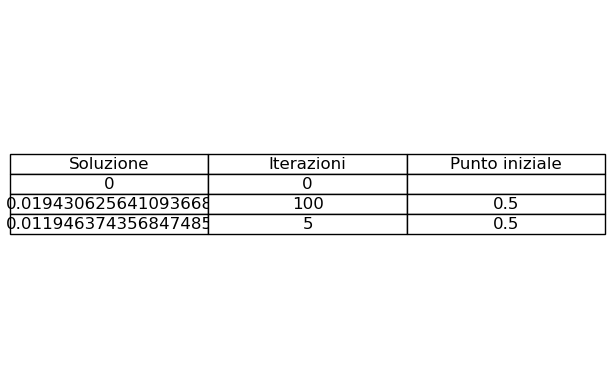

In [9]:
homework1(f, df, g, x0=0.5, max_iter=100, epsilon=1e-4, alfa=-10, beta=10, epsilon1=1e-4, epsilon2=1e-4, a=0, b=1)

Seconda funzione


2. $f(x) = x^2 -cos(x)   (g(x) = \sqrt{cos(x)})$


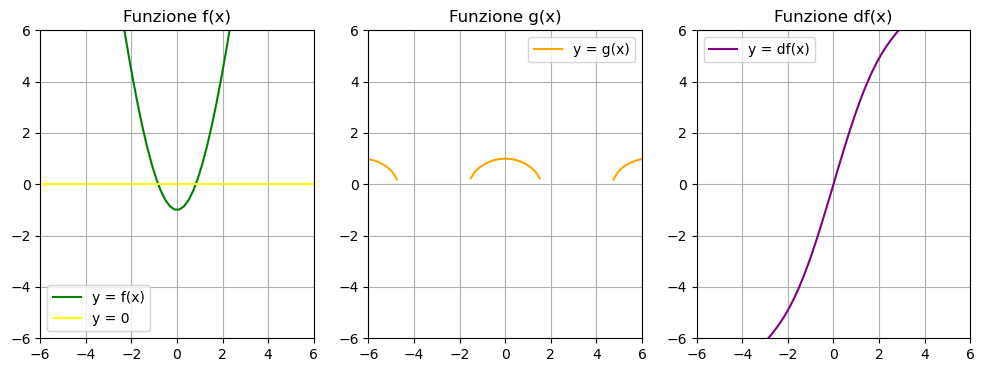

In [10]:
f = lambda x: x*x - np.cos(x)
df = lambda x: 2*x + np.sin(x)
g = lambda x: np.sqrt(np.where(np.cos(x) >= 0, np.cos(x), np.nan))

sp(f, g, df)

Variazione del punto iniziale e intervallo


Metodo di Bisezione:
a = 0, b = 1
Convergenza raggiunta dopo 20 iterazioni.
Lo zero calcolato è 0.824131965637207

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 18 iterazioni
Lo zero calcolato è 0.8241321092644079

Metodo di Newton:
La derivata è zero. Il metodo di Newton non può essere applicato.


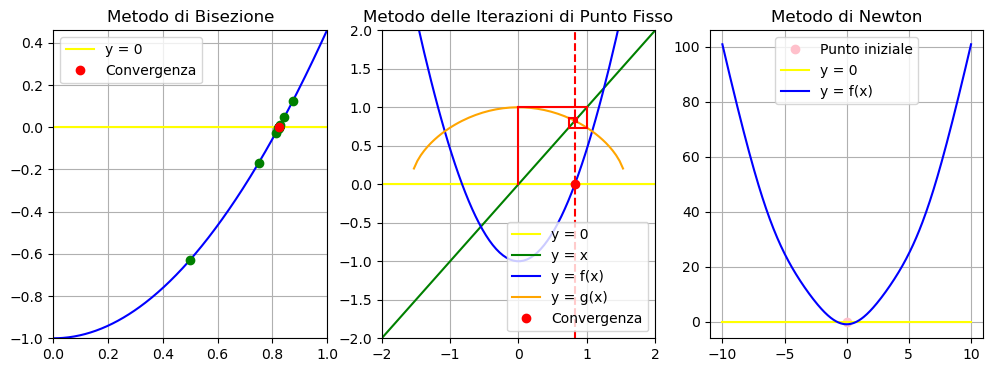

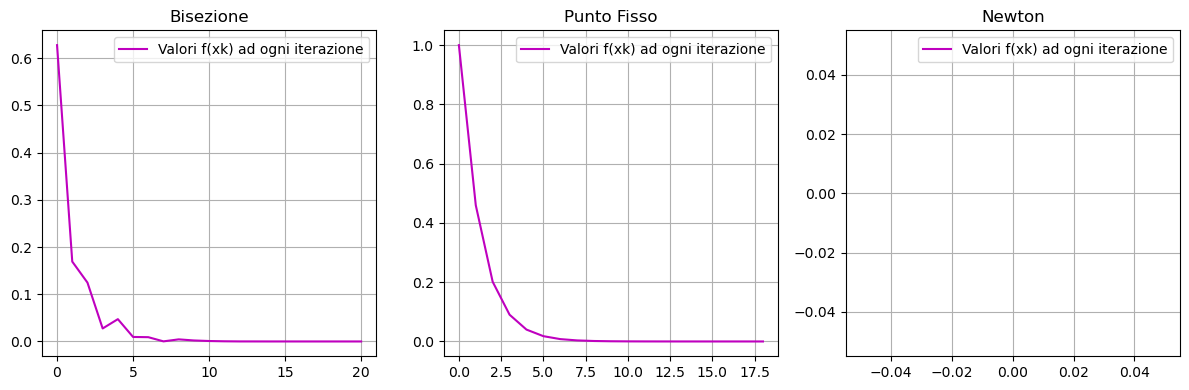

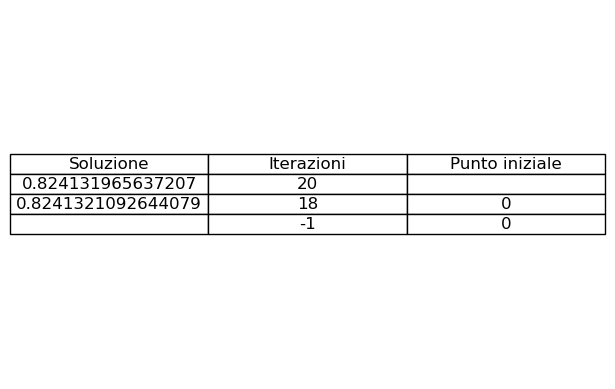


Metodo di Bisezione:
a = 0, b = 1
Convergenza raggiunta dopo 20 iterazioni.
Lo zero calcolato è 0.824131965637207

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 17 iterazioni
Lo zero calcolato è 0.8241325964401948

Metodo di Newton:
Convergenza raggiunta dopo 4 iterazioni
Lo zero calcolato è 0.8241323124099124


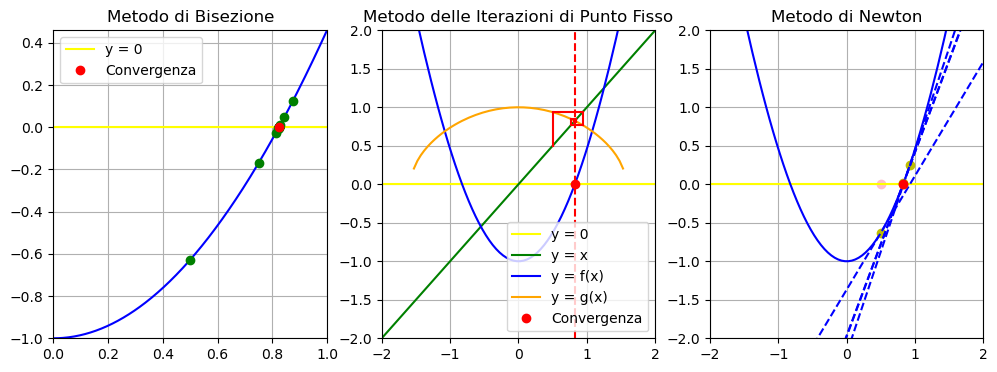

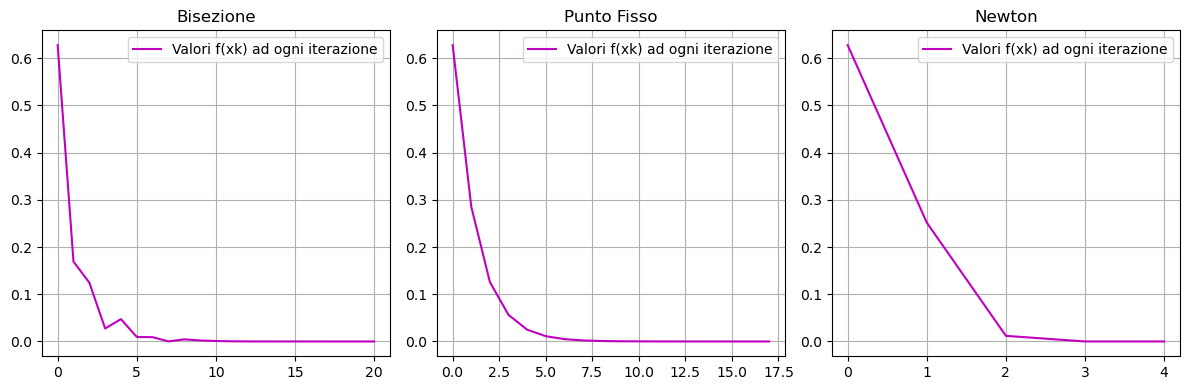

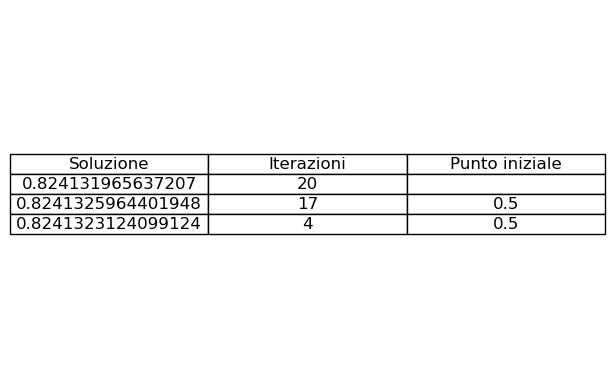


Metodo di Bisezione:
a = 1, b = 2
Il metodo di bisezione non può essere applicato.

Metodo delle Iterazioni di Punto Fisso:
Il metodo delle iterazioni di punto fisso non può essere applicato.
Punto iniziale non appartiene al dominio della funzione g(x).

Metodo di Newton:
Convergenza raggiunta dopo 4 iterazioni
Lo zero calcolato è 0.824132342922598


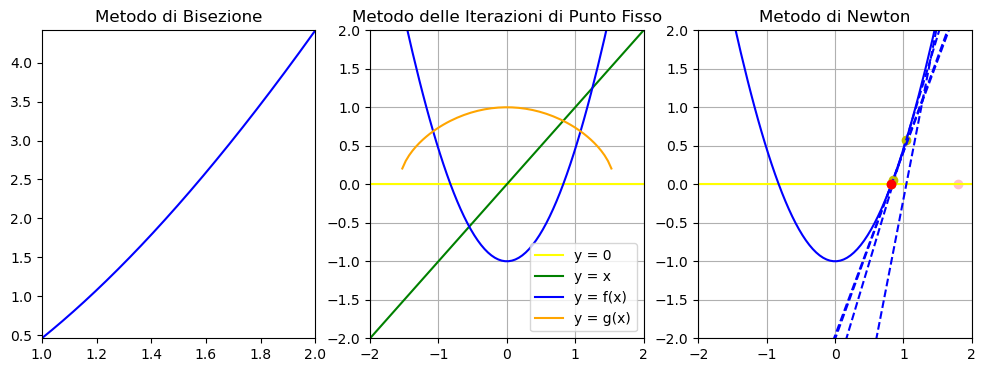

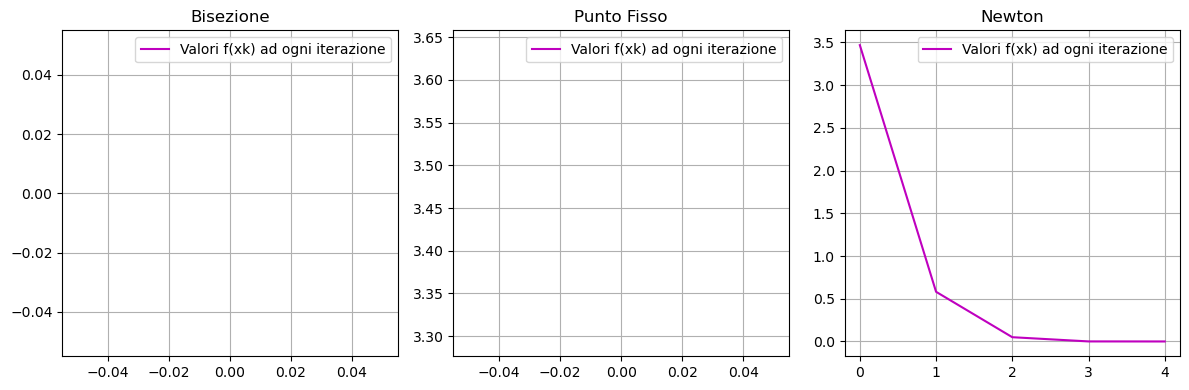

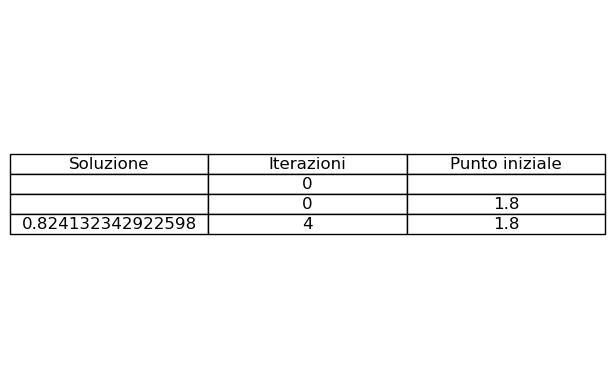


Metodo di Bisezione:
a = 2, b = 3
Il metodo di bisezione non può essere applicato.

Metodo delle Iterazioni di Punto Fisso:
Il metodo delle iterazioni di punto fisso non può essere applicato.
Punto iniziale non appartiene al dominio della funzione g(x).

Metodo di Newton:
Convergenza raggiunta dopo 5 iterazioni
Lo zero calcolato è 0.824132312305334


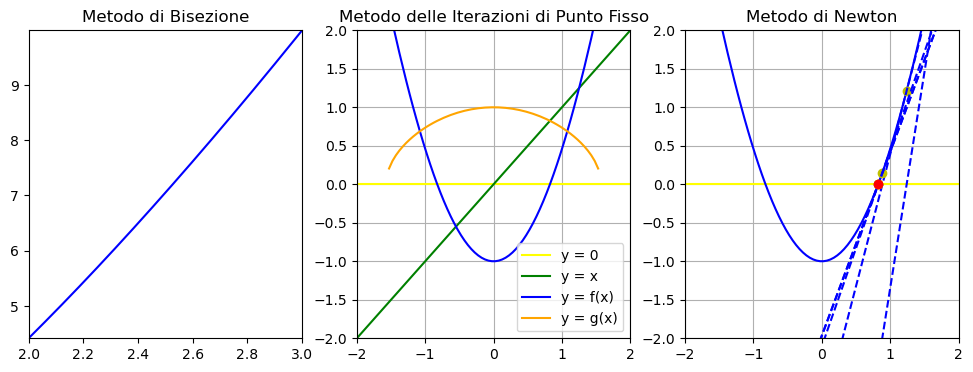

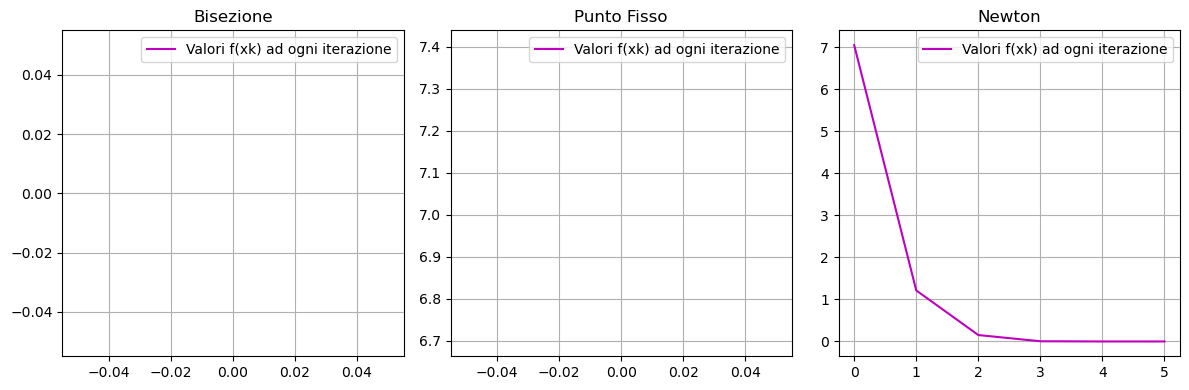

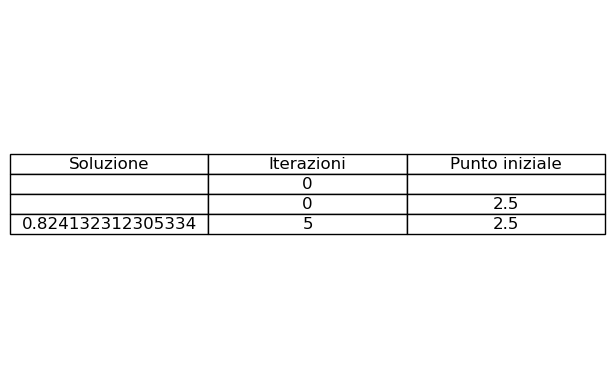

In [11]:

homework1(f, df, g, x0=0, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=0.5, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=1.8, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=1, b=2)
homework1(f, df, g, x0=2.5, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=2, b=3)

Variazione della tolleranza


Metodo di Bisezione:
a = 0, b = 2
Convergenza raggiunta dopo 14 iterazioni.
Lo zero calcolato è 0.8240966796875

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 11 iterazioni
Lo zero calcolato è 0.8241687585347371

Metodo di Newton:
Convergenza raggiunta dopo 3 iterazioni
Lo zero calcolato è 0.8241461317281952


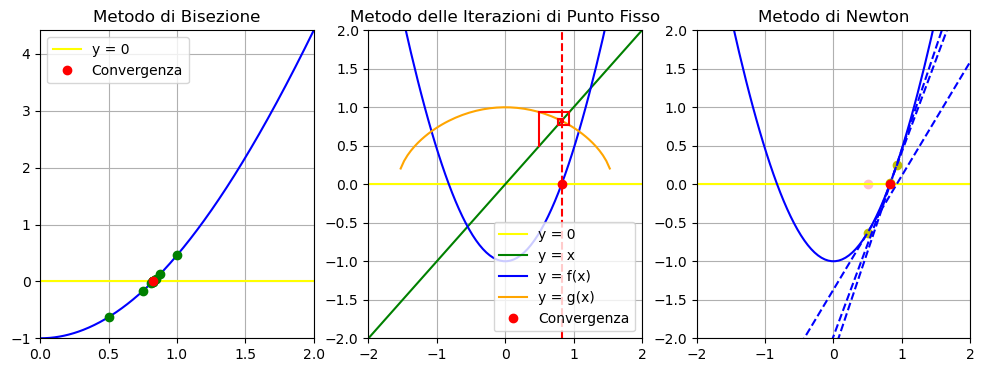

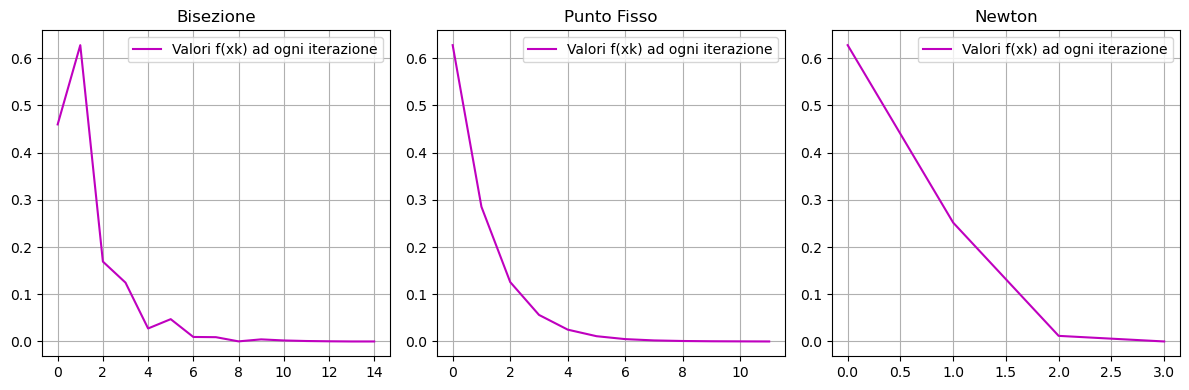

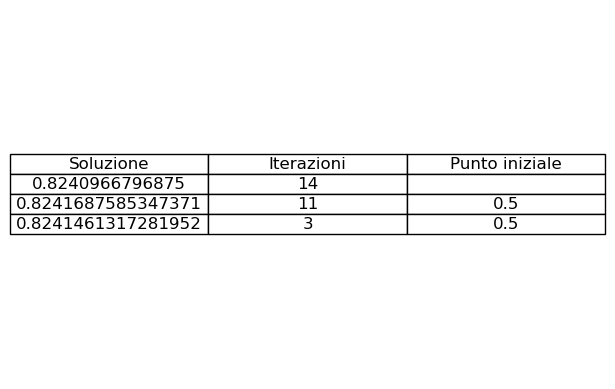

In [12]:
homework1(f, df, g, x0=0.5, max_iter=100, epsilon=1e-4, alfa=-10, beta=10, epsilon1=1e-4, epsilon2=1e-4, a=0, b=2)

Terza funzione


3. $f(x) = sin(x) − x/2 (g(x) = 2sin(x))$


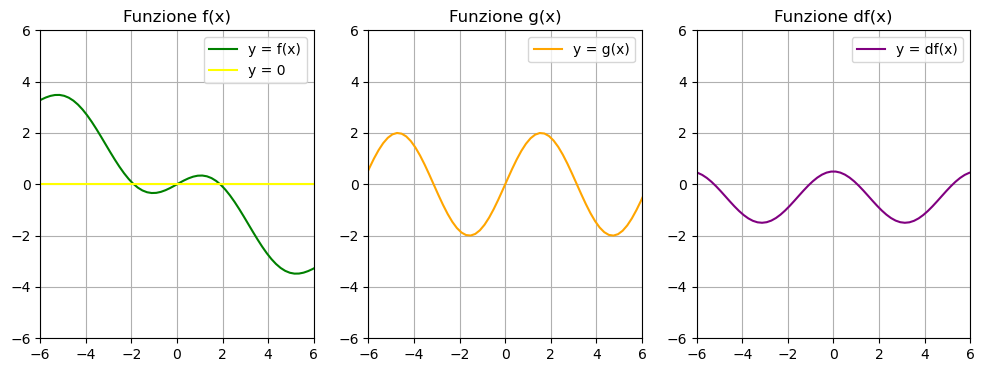

In [13]:
f = lambda x: np.sin(x) - x/2
df = lambda x: np.cos(x) - 1/2
g = lambda x: np.sin(x)*2

sp(f, g, df)

Variazione del punto iniziale e intervallo


Metodo di Bisezione:
a = 0, b = 1
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 1 iterazioni
Lo zero calcolato è 0.0

Metodo di Newton:
Convergenza raggiunta dopo 1 iterazioni.
Lo zero calcolato è 0.0
Convergenza raggiunta dopo 1 iterazioni
Lo zero calcolato è 0.0


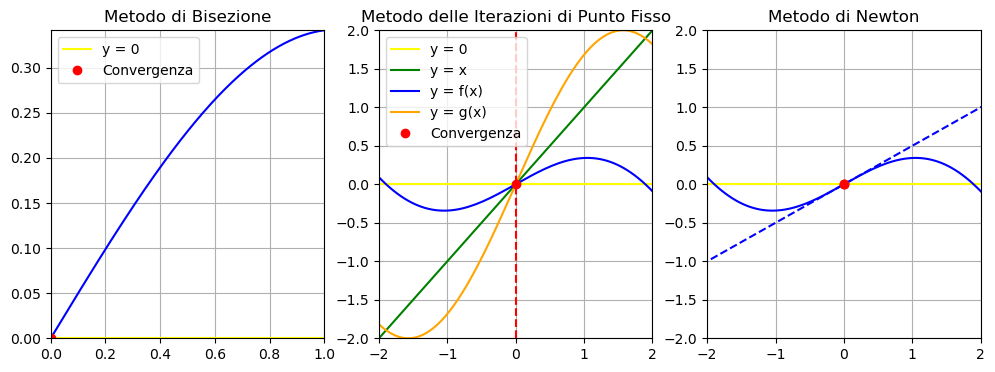

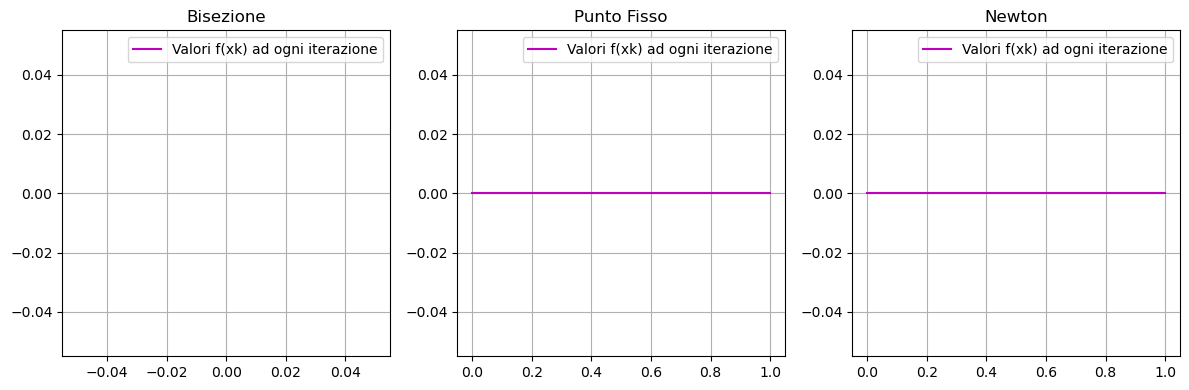

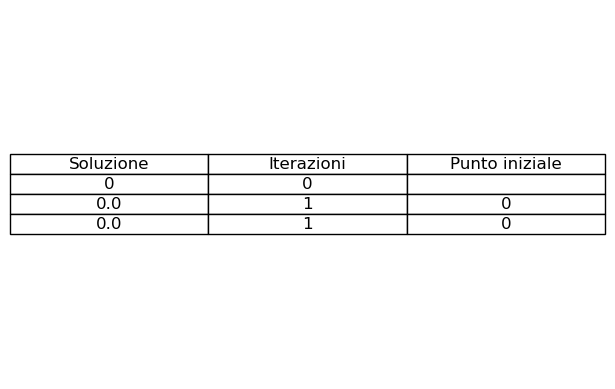


Metodo di Bisezione:
a = 0, b = 1
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 29 iterazioni
Lo zero calcolato è 1.895495156915764

Metodo di Newton:
Convergenza raggiunta dopo 3 iterazioni
Lo zero calcolato è -3.946500987334414e-10


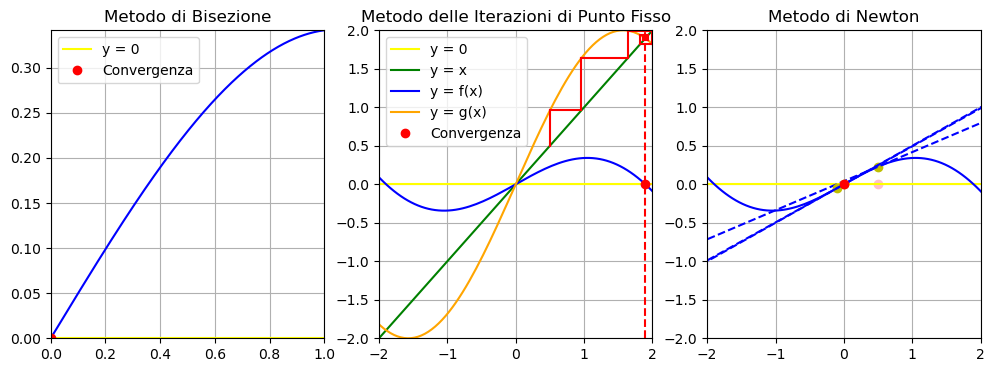

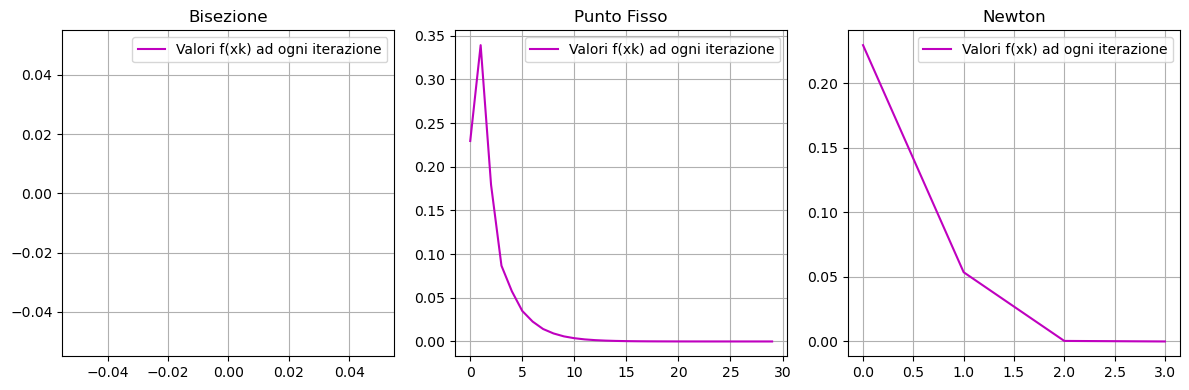

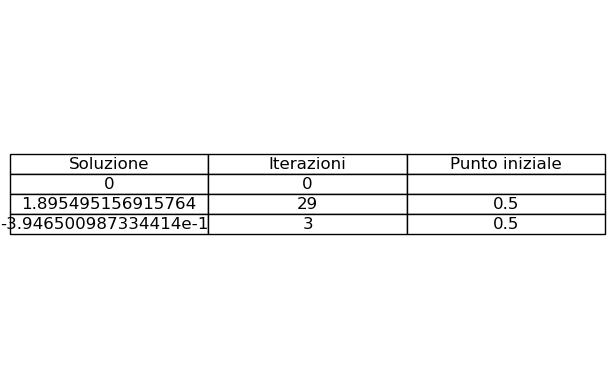


Metodo di Bisezione:
a = 0, b = 1
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 27 iterazioni
Lo zero calcolato è 1.895493071666415

Metodo di Newton:
Convergenza raggiunta dopo 6 iterazioni
Lo zero calcolato è -1.8954942678892686


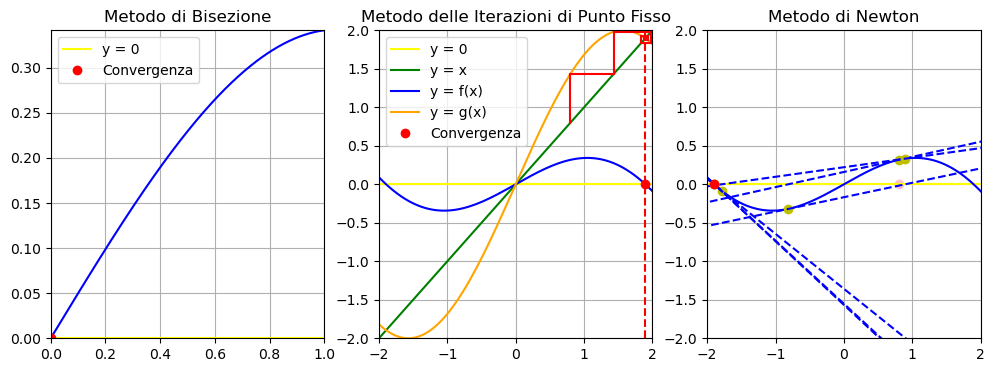

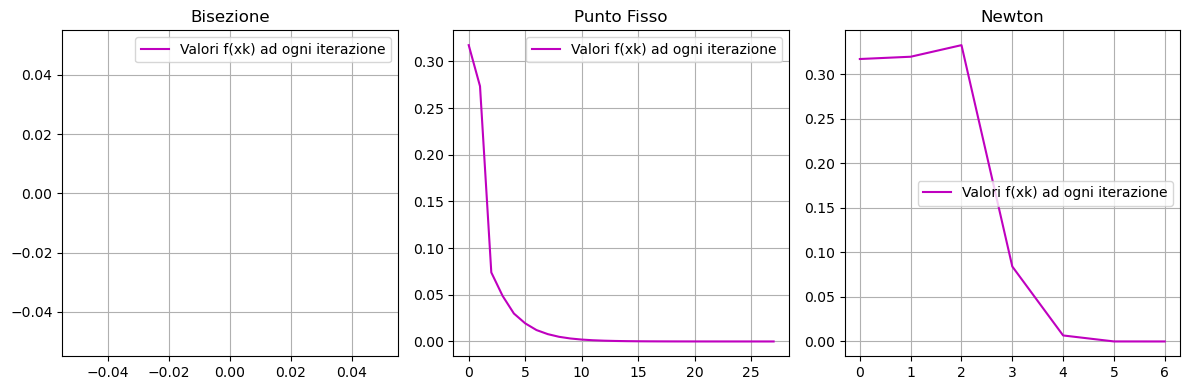

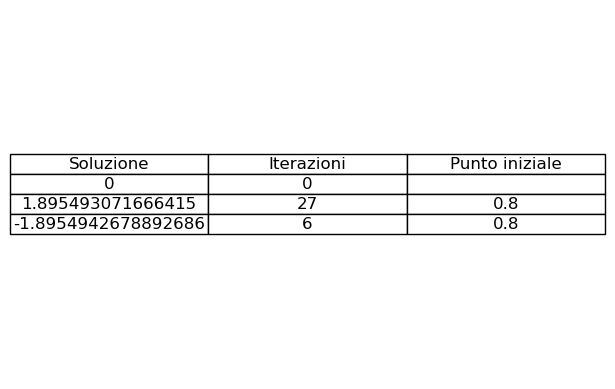


Metodo di Bisezione:
a = -2, b = -1
Convergenza raggiunta dopo 16 iterazioni.
Lo zero calcolato è -1.8954925537109375

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 22 iterazioni
Lo zero calcolato è -1.8954859042688768

Metodo di Newton:
Convergenza raggiunta dopo 4 iterazioni
Lo zero calcolato è -1.8954942764727707


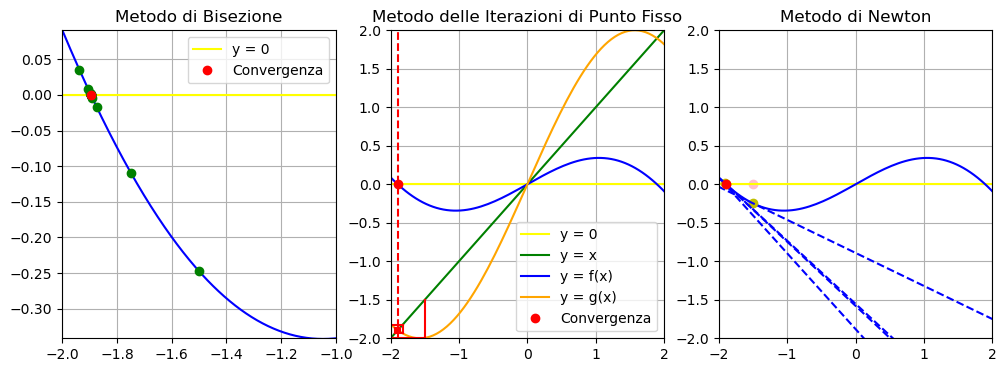

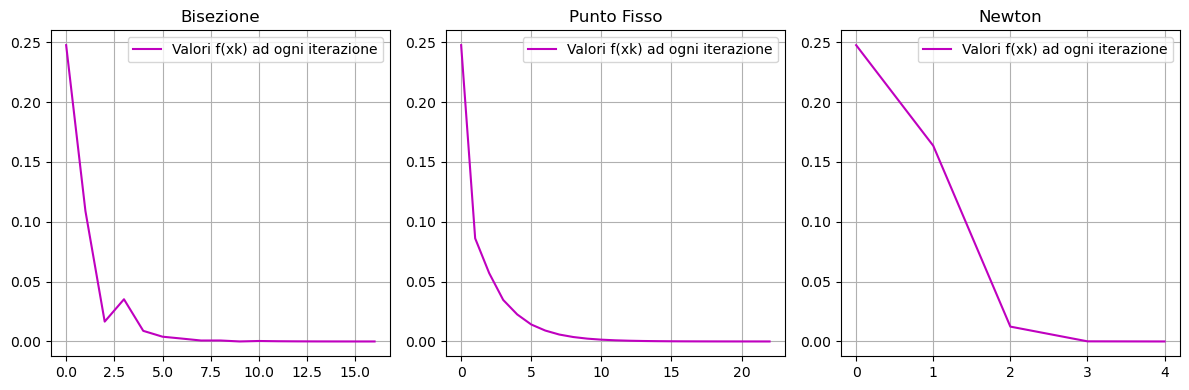

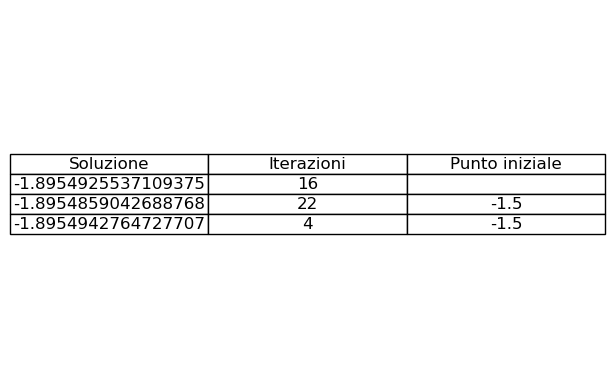

In [14]:

homework1(f, df, g, x0=0, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=0.5, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=0.8, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=-1.5, max_iter=100, epsilon=1e-5, alfa=-10, beta=10, epsilon1=1e-5, epsilon2=1e-5, a=-2, b=-1)


Variazione della tolleranza


Metodo di Bisezione:
a = 0, b = 1
Lo zero calcolato è 0

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 17 iterazioni
Lo zero calcolato è 1.895387354236375

Metodo di Newton:
Convergenza raggiunta dopo 5 iterazioni
Lo zero calcolato è -1.8955327159687811


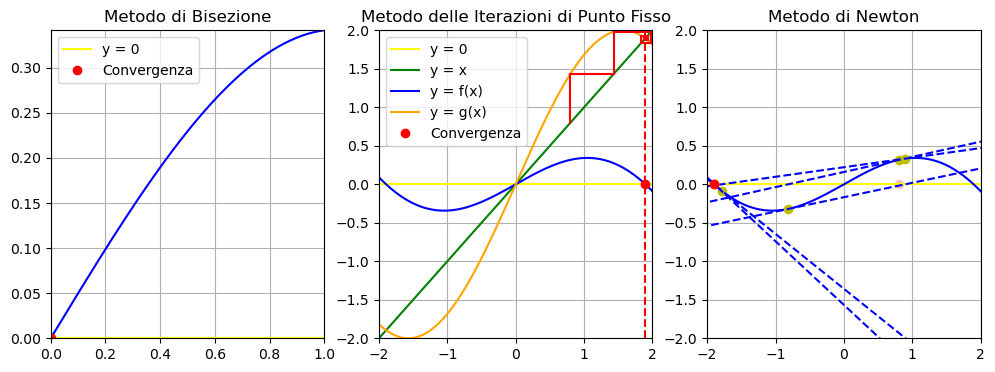

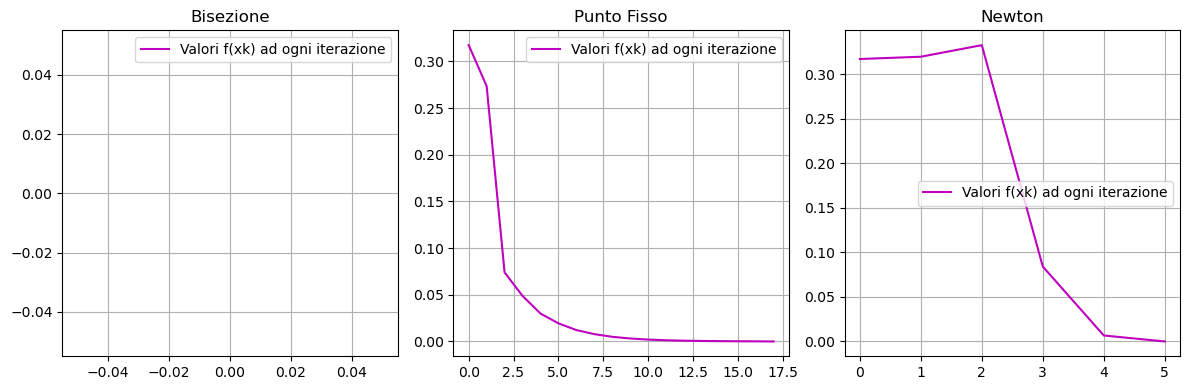

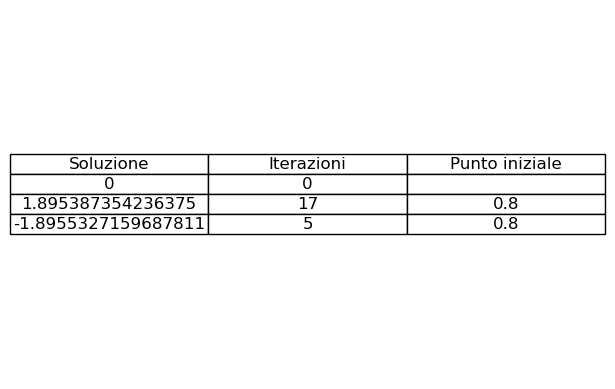

In [15]:
homework1(f, df, g, x0=0.8, max_iter=100, epsilon=1e-4, alfa=-10, beta=10, epsilon1=1e-4, epsilon2=1e-4, a=0, b=1)

Quarta funzione


4. $f(x) = e^x-3x  (g(x) = e^x/3)$


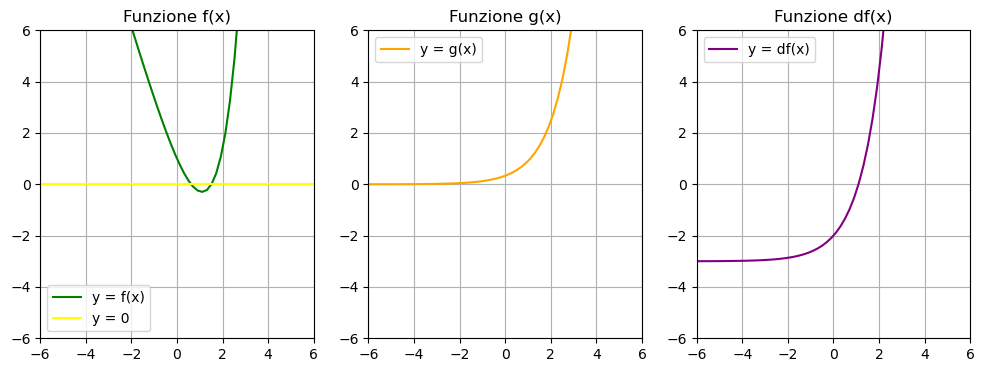

In [16]:
f = lambda x: np.exp(x) - 3*x 
df = lambda x: np.exp(x) - 3
g = lambda x: np.exp(x)/3

sp(f, g, df)

Variazione del punto iniziale e intervallo


Metodo di Bisezione:
a = 0, b = 1
Convergenza raggiunta dopo 18 iterazioni.
Lo zero calcolato è 0.6190605163574219

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 24 iterazioni
Lo zero calcolato è 0.6190602548789568

Metodo di Newton:
Convergenza raggiunta dopo 3 iterazioni
Lo zero calcolato è 0.6190612833553127


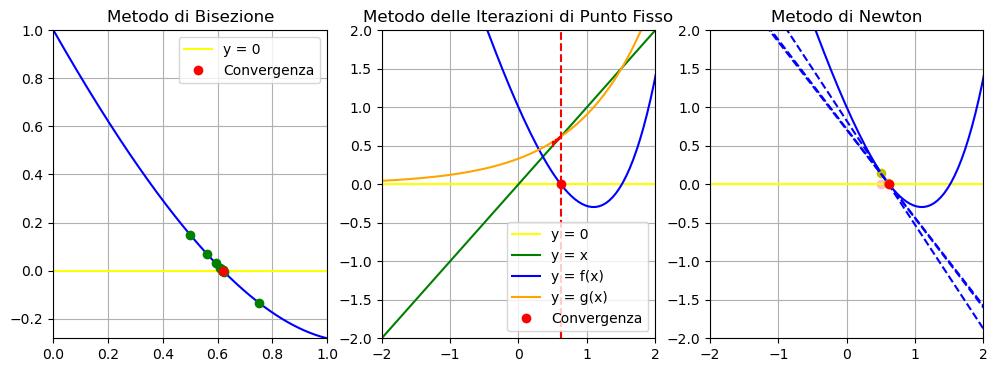

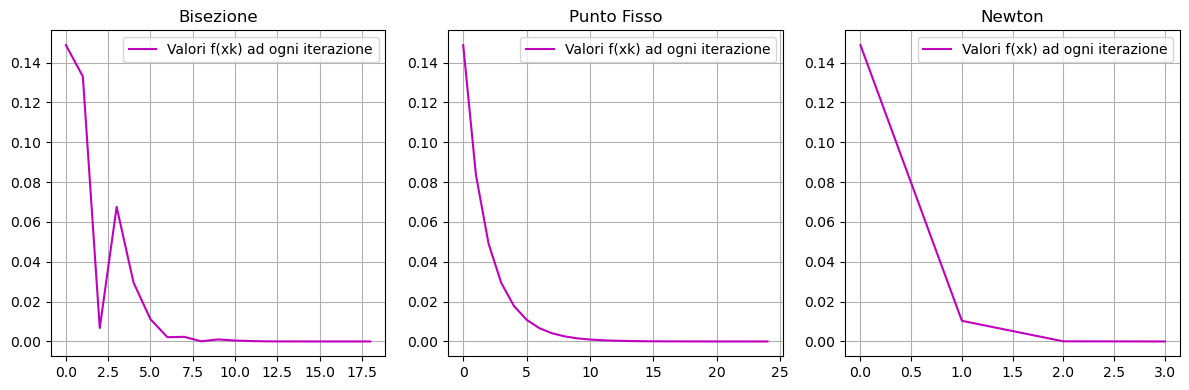

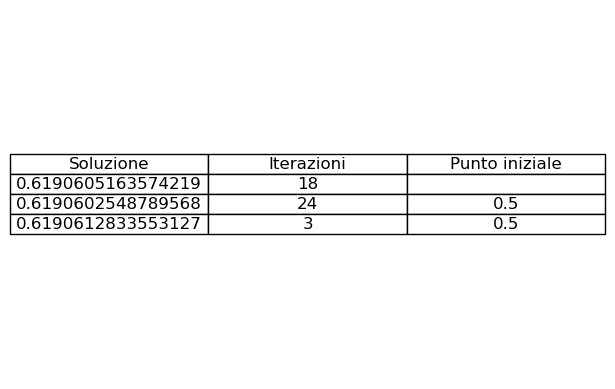


Metodo di Bisezione:
a = 0, b = 2
Il metodo di bisezione non può essere applicato.

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 28 iterazioni
Lo zero calcolato è 0.6190623625369498

Metodo di Newton:
Convergenza raggiunta dopo 5 iterazioni
Lo zero calcolato è 0.6190612833553127


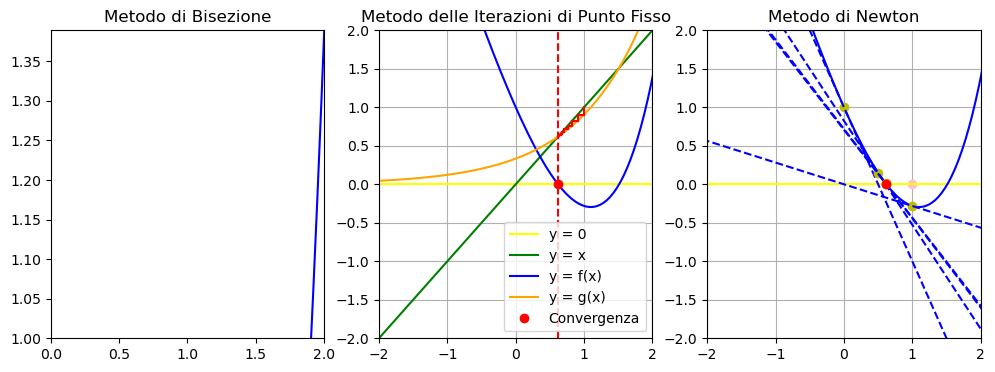

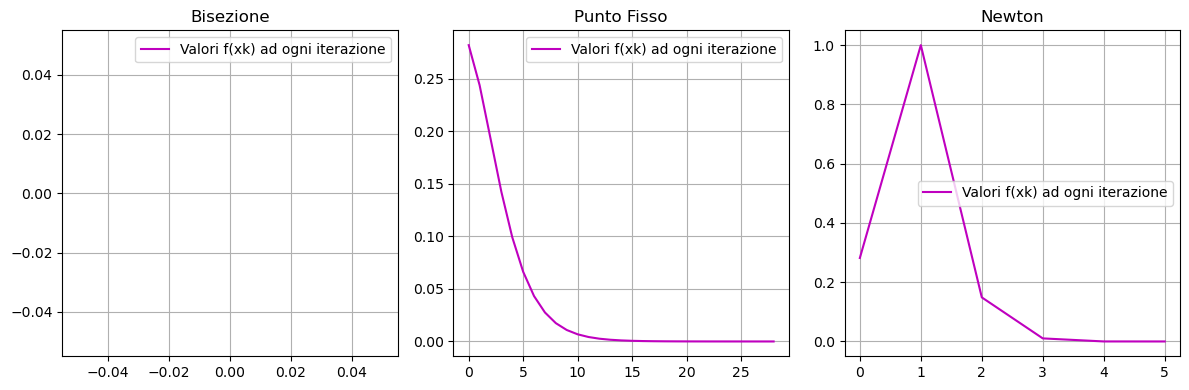

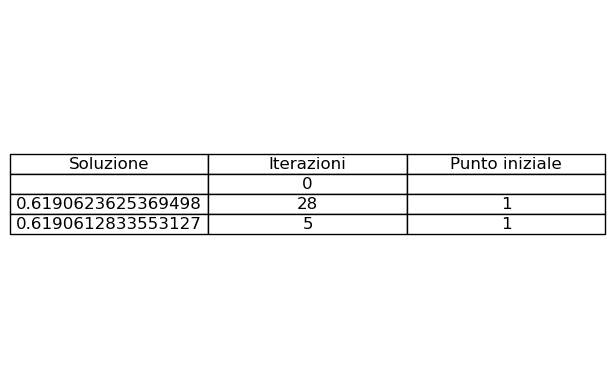


Metodo di Bisezione:
a = 2, b = 3
Il metodo di bisezione non può essere applicato.

Metodo delle Iterazioni di Punto Fisso:
Il metodo delle iterazioni di punto fisso non converge.

Metodo di Newton:
Convergenza raggiunta dopo 5 iterazioni
Lo zero calcolato è 1.512134620814894


C:\Users\alext\AppData\Local\Temp\ipykernel_19668\1854523274.py:1: RuntimeWarning: overflow encountered in exp
  f = lambda x: np.exp(x) - 3*x
C:\Users\alext\AppData\Local\Temp\ipykernel_19668\1854523274.py:3: RuntimeWarning: overflow encountered in exp
  g = lambda x: np.exp(x)/3


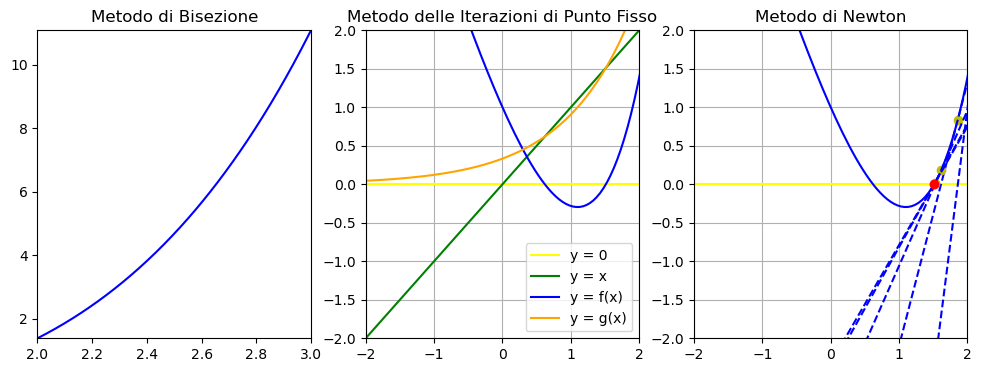

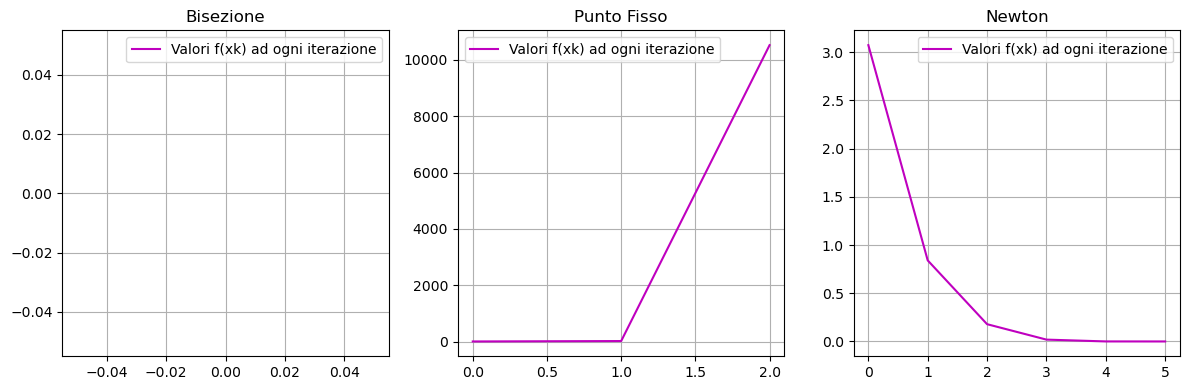

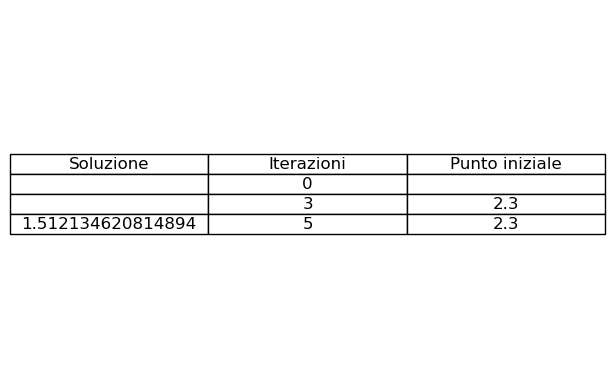

In [17]:

homework1(f, df, g, x0=0.5, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=1)
homework1(f, df, g, x0=1, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=0, b=2)
homework1(f, df, g, x0=2.3, max_iter=100, epsilon=1e-6, alfa=-10, beta=10, epsilon1=1e-6, epsilon2=1e-6, a=2, b=3)

Variazione della tolleranza


Metodo di Bisezione:
a = 0.8, b = 2
Convergenza raggiunta dopo 14 iterazioni.
Lo zero calcolato è 1.5121337890624997

Metodo delle Iterazioni di Punto Fisso:
Convergenza raggiunta dopo 18 iterazioni
Lo zero calcolato è 0.6191914001054893

Metodo di Newton:
Convergenza raggiunta dopo 4 iterazioni
Lo zero calcolato è 0.6189967797415397


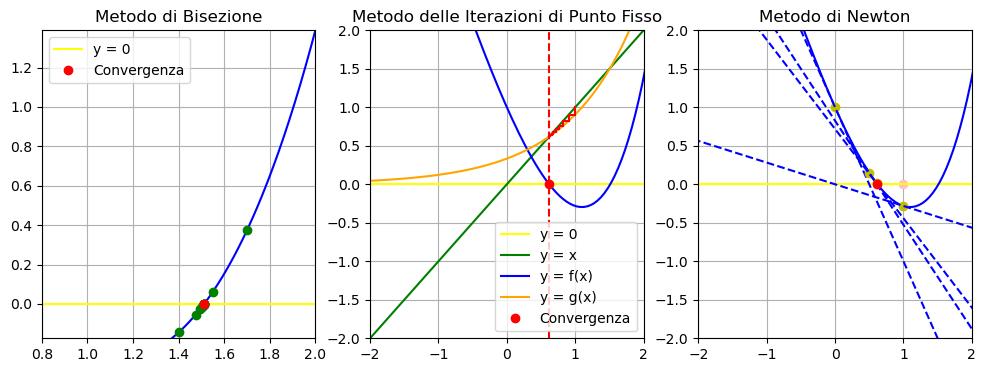

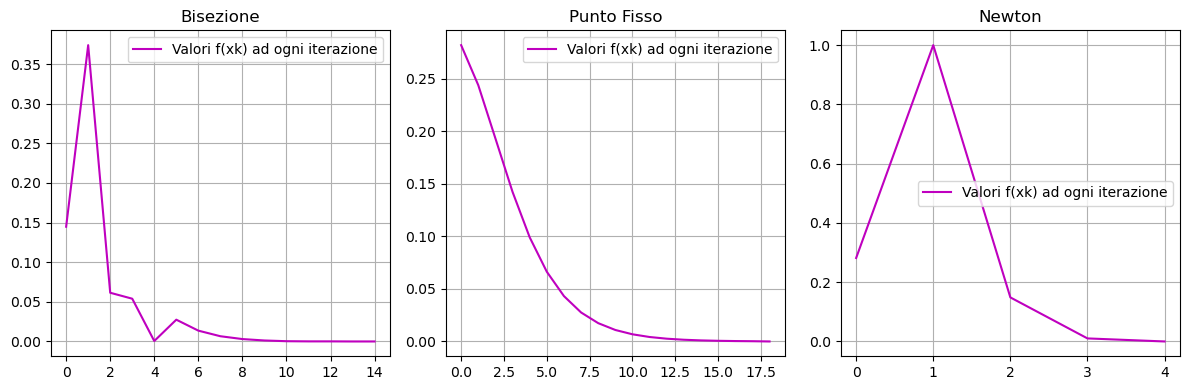

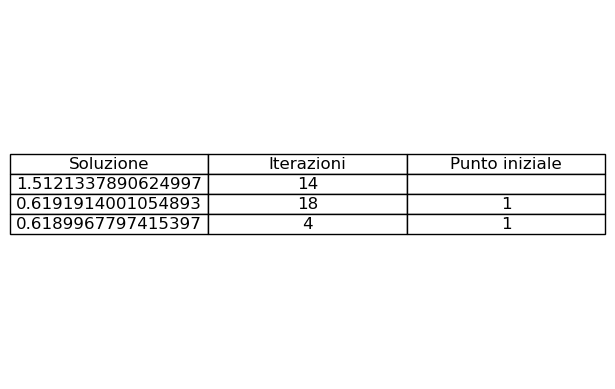

In [18]:
homework1(f, df, g, x0=1, max_iter=100, epsilon=1e-4, alfa=-10, beta=10, epsilon1=1e-4, epsilon2=1e-4, a=0.8, b=2)
